In [ ]:
import pandas as pd
import numpy as np
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # registers the 'science' / 'ieee' styles
from collections import Counter
import matplotlib.patches as mpatches
import os
import seaborn as sns

# Define options
num_warehouses_options = [2, 3, 4, 5]
num_customers_options = [50, 100, 200, 400]
capacity_distribution_options = ['uniform', 'uneven']

# Initialize an empty list to store dataframes
results_list = []

# Loop through parameter combinations
for num_warehouses in num_warehouses_options:
    for num_customers in num_customers_options:
        for capacity_distribution in capacity_distribution_options:
            # Construct the filename
            filename = f'results/full_tables/full_results_w_{num_warehouses}_c_{num_customers}_d_{capacity_distribution}.csv'
            read_df = pd.read_csv(filename)

            # Keep the last stored result for each policy (in case of multiple runs)
            read_df = read_df.drop_duplicates(subset='Policy', keep='last').reset_index(drop=True)

            # Create a new dataframe
            new_df = pd.DataFrame()
            new_df['num_warehouses'] = [num_warehouses] * len(read_df)
            new_df['num_customers'] = [num_customers] * len(read_df)
            new_df['capacity_distribution'] = [capacity_distribution] * len(read_df)

            # Add policy columns
            new_df['policy'] = read_df['Policy']
            new_df['avg_reward'] = read_df['MeanReward']
            new_df['std_reward'] = read_df['StdReward']
            new_df['mean_time'] = read_df['MeanTime']
            new_df['std_time'] = read_df['StdTime']
            new_df['all_rewards'] = read_df['AllRewards'].apply(lambda x: eval(x) if isinstance(x, str) else x)
            new_df['all_distance_ranks_n_vectors'] = read_df['AllFacilityProximity'].apply(lambda x: eval(x) if isinstance(x, str) else x)

            #Get All_Distance_ranks single vector
            new_df['all_distance_ranks_single_vector'] = new_df['all_distance_ranks_n_vectors'].apply(lambda x: [item for sublist in x for item in sublist] if isinstance(x, list) else [])

            #Get All_Times single vector
            new_df['all_times_n_vectors'] = read_df['AllTimes'].apply(lambda x: eval(x) if isinstance(x, str) else x)
            new_df['all_times_single_vector'] = new_df['all_times_n_vectors'].apply(lambda x: [item for sublist in x for item in sublist] if isinstance(x, list) else [])

            # Append to list
            results_list.append(new_df)

# Concatenate all dataframes into a single DataFrame
results = pd.concat(results_list, ignore_index=True)

family_cols = ['num_warehouses', 'num_customers', 'capacity_distribution']


def _as_reward_array(x):
    """AllRewards: flat list of per-episode total rewards -> 1-D float array."""
    if isinstance(x, str):
        return np.asarray(ast.literal_eval(x), dtype=float)
    return np.asarray(x, dtype=float)


def _family_of(r):
    return results[(results['num_warehouses'] == r['num_warehouses']) &
                   (results['num_customers'] == r['num_customers']) &
                   (results['capacity_distribution'] == r['capacity_distribution'])]


# --------------------------------------------------------------------- PHS comparison
def _row_stats_phs(r):
    fam = _family_of(r)
    phs_cost = -_as_reward_array(fam[fam['policy'] == 'perfect_hindsight']['all_rewards'].iloc[0])
    cost_pi = -_as_reward_array(r['all_rewards'])

    assert len(cost_pi) == len(phs_cost), "episodes not aligned - cannot pair"
    assert (r['policy'] == 'perfect_hindsight') or ((cost_pi - phs_cost) >= 0).all(), \
        f"PHS not per-episode optimal vs {r['policy']} - episodes misaligned"

    delta = cost_pi - phs_cost
    avg_phs = phs_cost.mean()
    avg_delta, std_delta = delta.mean(), delta.std(ddof=1)
    return pd.Series({
        'delta_phs_vector': delta,
        'avg_delta_phs': avg_delta,
        'std_delta_phs': std_delta,
        'gap_phs_vector': delta / phs_cost * 100.0,
        'avg_gap_phs': avg_delta / avg_phs * 100.0,
        'std_gap_phs': std_delta / avg_phs * 100.0,
    })

results[['delta_phs_vector', 'avg_delta_phs', 'std_delta_phs',
         'gap_phs_vector','avg_gap_phs', 'std_gap_phs']] = results.apply(_row_stats_phs, axis=1)


# --------------------------------------------------------------------- EVF comparison
# Same construction, against the exact value function (EVF) policy. Only defined for
# num_customers == 50 (EVF is only tractable there); NaN/empty otherwise.
def _row_stats_evf(r):
    empty = pd.Series({
        'delta_optimal_vector': np.array([]),
        'avg_delta_optimal': np.nan, 'std_delta_optimal': np.nan,
        'avg_gap_optimal': np.nan, 'std_gap_optimal': np.nan,
    })
    if r['num_customers'] != 50:
        return empty
    fam = _family_of(r)
    evf_rows = fam[fam['policy'] == 'exact_value_function']
    if evf_rows.empty:
        return empty

    evf_cost = -_as_reward_array(evf_rows['all_rewards'].iloc[0])
    cost_pi = -_as_reward_array(r['all_rewards'])
    delta = cost_pi - evf_cost
    avg_evf = evf_cost.mean()
    avg_delta, std_delta = delta.mean(), delta.std(ddof=1)
    return pd.Series({
        'delta_optimal_vector': delta,
        'avg_delta_optimal': avg_delta,
        'std_delta_optimal': std_delta,
        'avg_gap_optimal': avg_delta / avg_evf * 100.0,
        'std_gap_optimal': std_delta / avg_evf * 100.0,
    })

results[['delta_optimal_vector', 'avg_delta_optimal', 'std_delta_optimal',
         'avg_gap_optimal', 'std_gap_optimal']] = results.apply(_row_stats_evf, axis=1)

# quick sanity print (PHS family_gap should be ~0)
_phs_gap = results.loc[results['policy'] == 'perfect_hindsight', 'avg_gap_phs']
print("Consolidation done.", f"results: {len(results)} rows (policy x family).")
if not _phs_gap.empty:
    print(f"  PHS family_gap (should be ~0): {_phs_gap.abs().max():.6f}")

Consolidation done. results: 104 rows (policy x family).
  PHS family_gap (should be ~0): 0.000000


In [3]:
# ---- Global plot styling ----
# Fixed, ordered color vector shared by every plot below except scatter_time_performance
# (which keeps its own long-standing manual palette). Colors are used in order: a plot
# that needs 2 colors gets the first 2, one that needs 12 gets all 12, and so on - edit
# this list directly to change what every plot uses. The defaults below are sampled
# once from 'cividis' (perceptually uniform, so monotonic in greyscale) at 12 evenly
# spaced points, which makes them colorblind-safe and print/greyscale-safe as a set.
import matplotlib.pyplot as plt

COLOR_PALETTE = [
     '#2b83ba', '#fdae61', '#abdda4','#d7191c','#ffffbf'
]

#d7191c
#fdae61
#ffffbf
#abdda4
#2b83ba

# Uniform font sizes applied to every plot's axis labels, tick labels, and legend below.
TITLE_FONT_SIZE = 12         # plot title
FONT_SIZE_LABEL = 12          # xlabel / ylabel
FONT_SIZE_TICK = 12           # x/y tick labels
FONT_SIZE_LEGEND = 12         # legend entries
FONT_SIZE_LEGEND_TITLE = 12   # legend title

def get_colors(n):
    """First n colors from COLOR_PALETTE, in order (cycles if n exceeds its length)."""
    return [COLOR_PALETTE[i % len(COLOR_PALETTE)] for i in range(n)]


all_policy_colors = [
    '#1f78b4', "#50c2ff", '#b2df8a', '#33a02c', '#fb9a99', 
    '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a',
     "#e704eb", "#000000"
]

#plt.style.use(['science', 'ieee'])
plt.style.use(['science', 'muted', 'no-latex'])

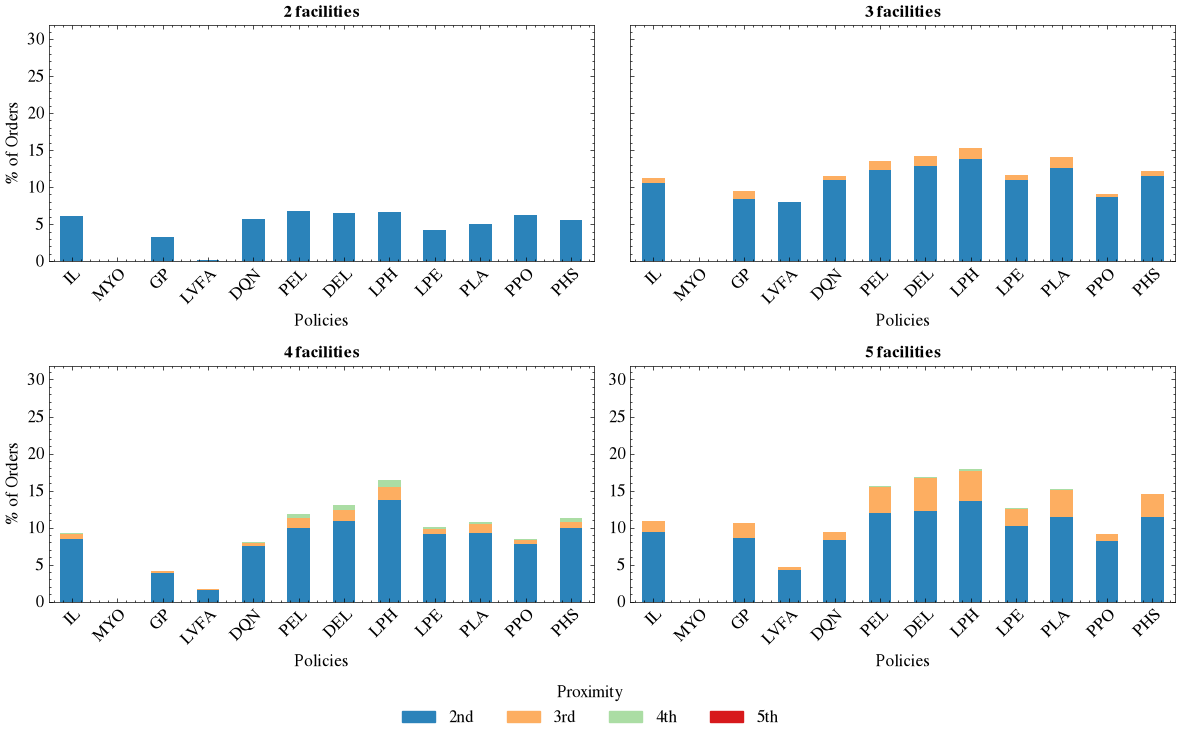

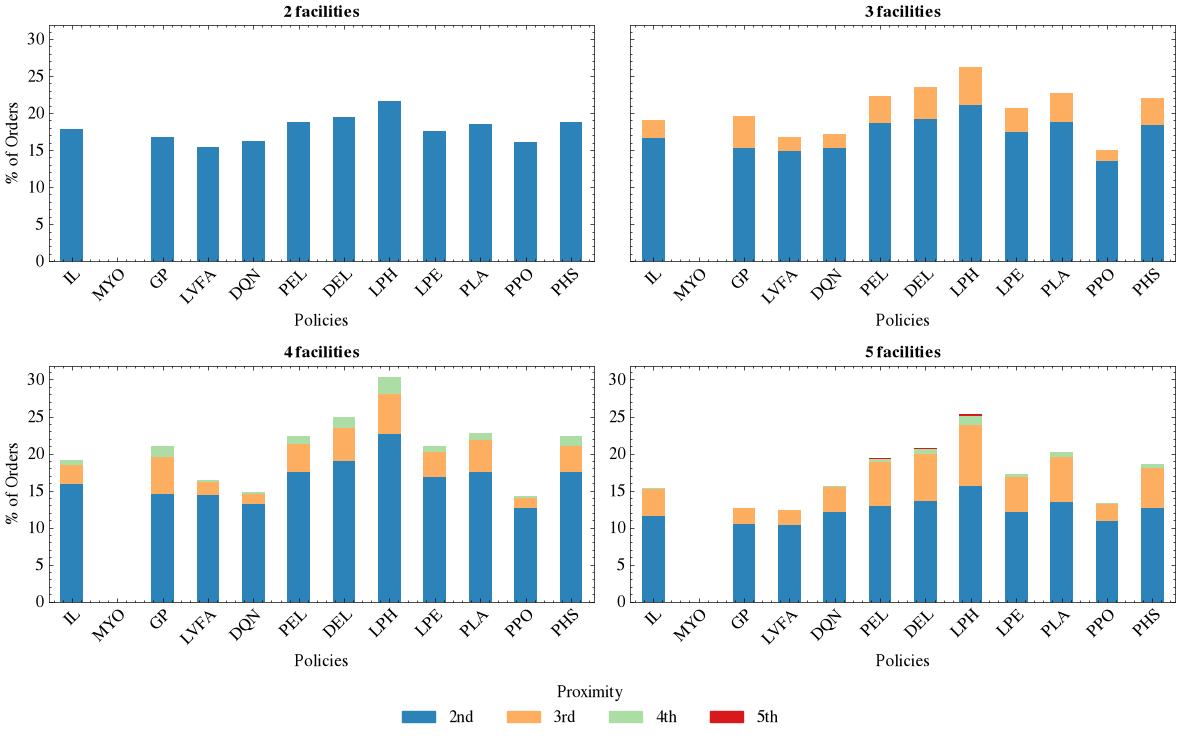

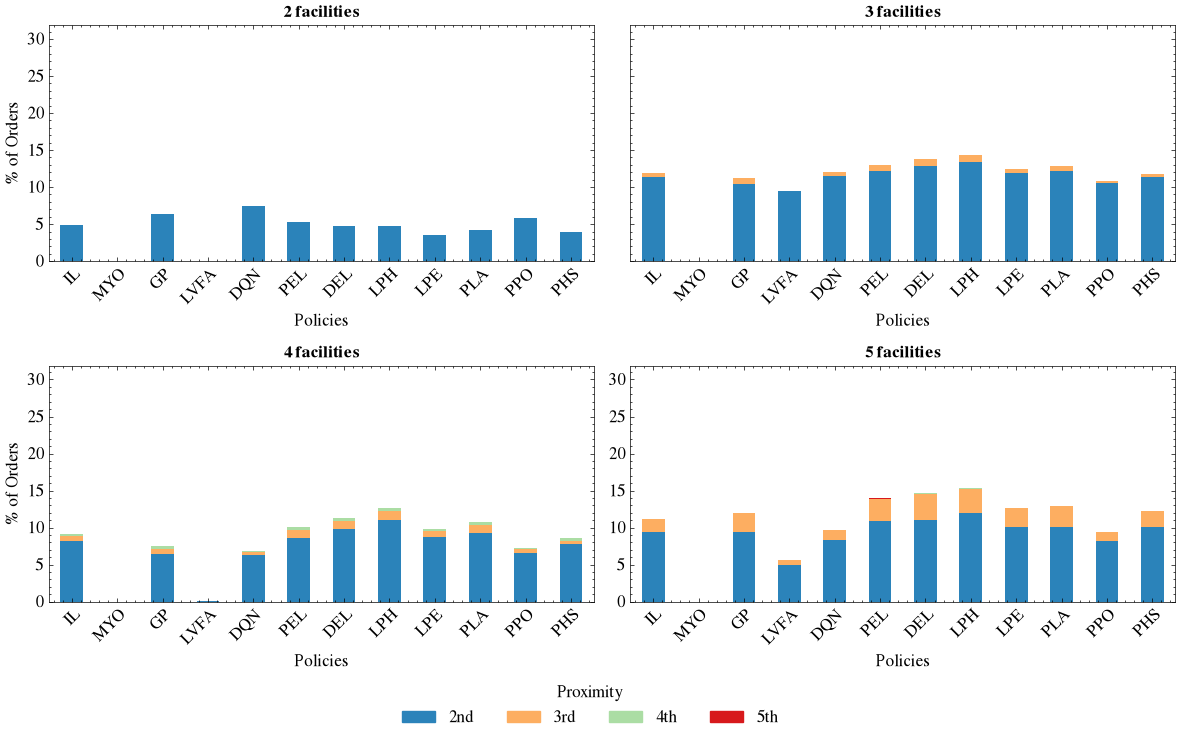

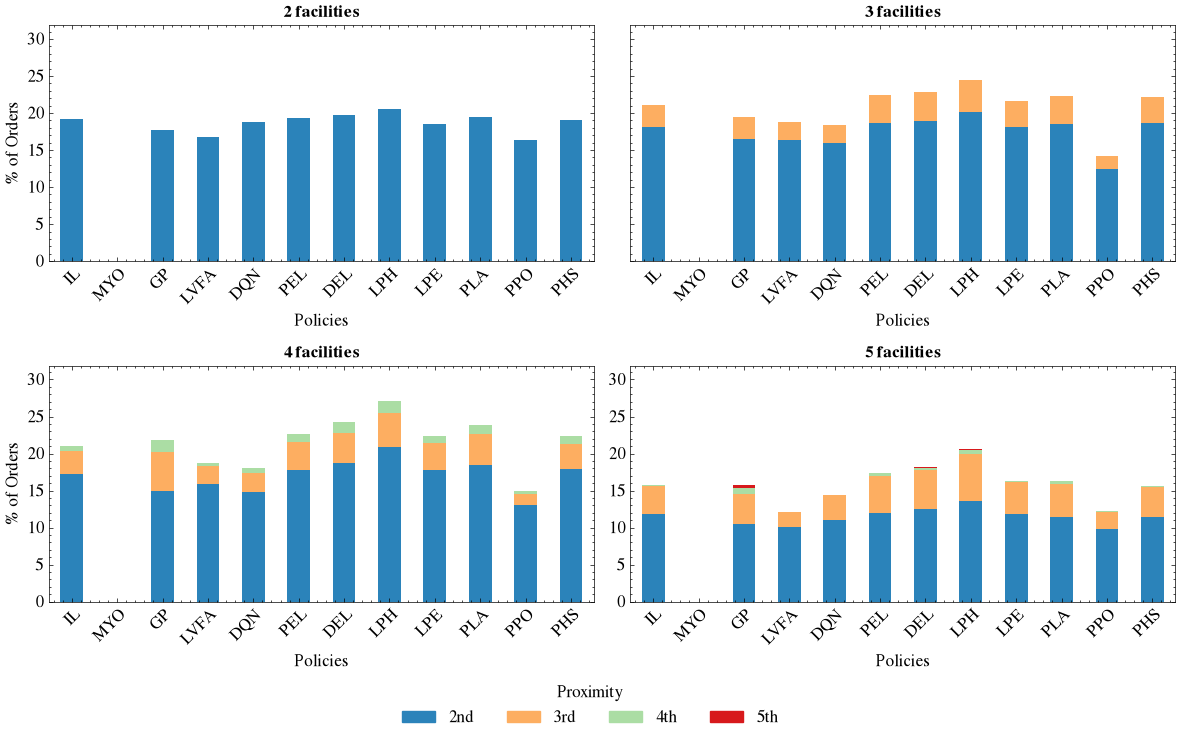

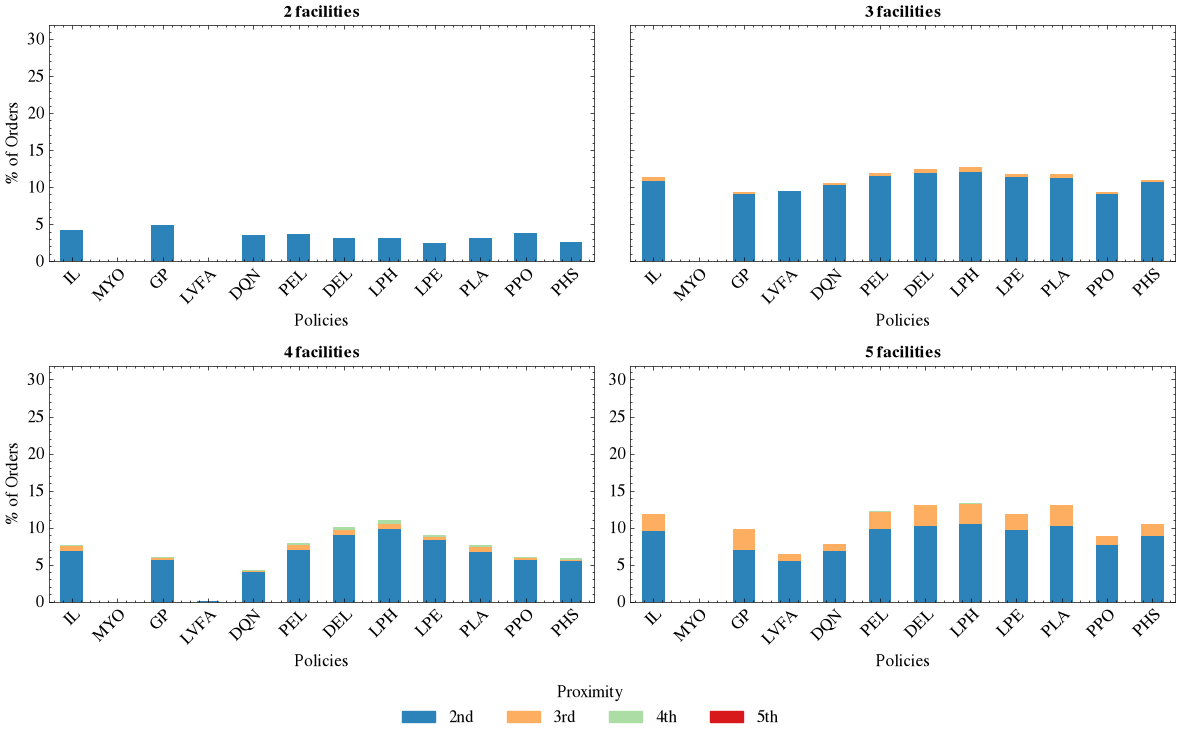

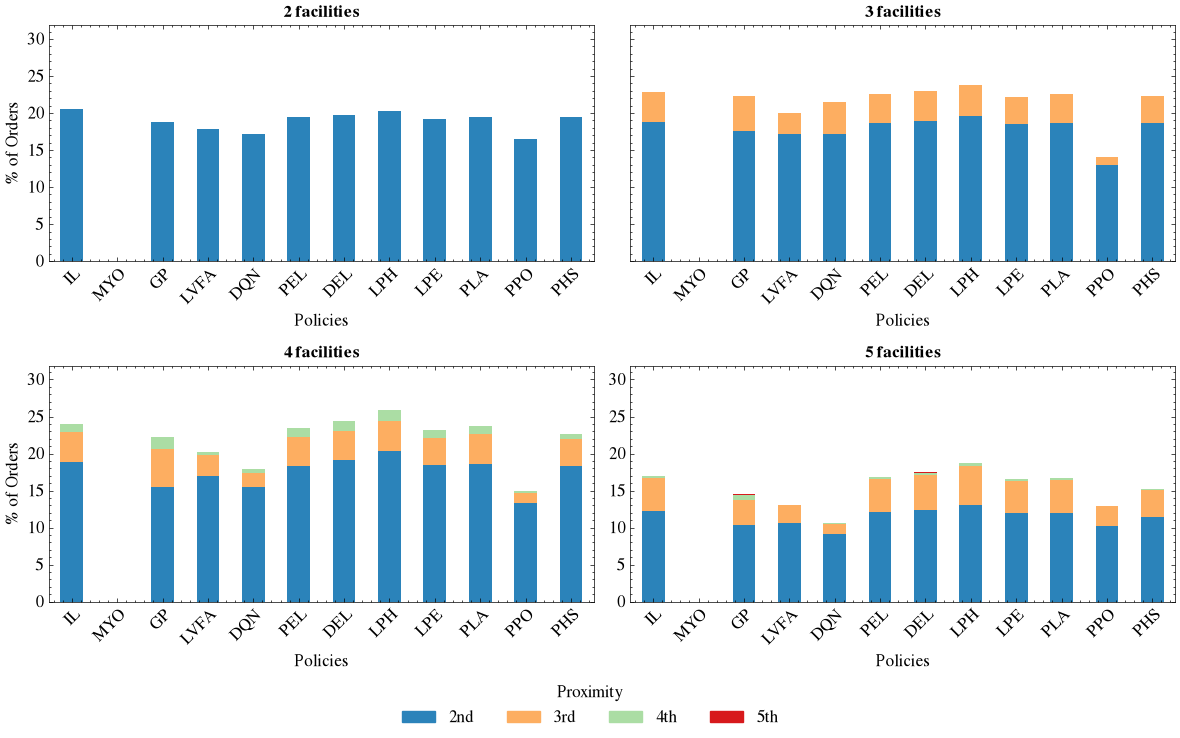

In [8]:
def _ordinal(n):
    n = int(n)
    if 10 <= n % 100 <= 20:
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suffix}"

def build_non_closest_df(df_cfg, num_warehouses, policy_order_with_phs):
    rows = []

    for policy in policy_order_with_phs:
        row = df_cfg[df_cfg["policy"] == policy]
        if row.empty:
            continue

        ranks = row.iloc[0]["all_distance_ranks_single_vector"]
        if not isinstance(ranks, list):
            continue

        flat_ranks = []
        for r in ranks:
            if isinstance(r, list):
                flat_ranks.extend(r)
            else:
                flat_ranks.append(int(r))

        total = len(flat_ranks)
        if total == 0:
            continue

        counts = Counter(r for r in flat_ranks if 2 <= int(r) <= num_warehouses)
        for prox_rank, count in counts.items():
            rows.append(
                {
                    "policy": policy,
                    "proximity": _ordinal(prox_rank),
                    "rank_pct": 100 * count / total,
                }
            )

    return pd.DataFrame(rows)

policy_order = ["imitation_learning", "myopic", "genetic_programming", "linear_value_function_approximation", "deep_q_networks", "point_estimate_lookahead", "distributional_estimate_lookahead", "linear_programming_heuristic", "linear_programming_exact", "parameterized_lookahead_approximation", "proximal_policy_optimization", "perfect_hindsight"]
labels_dict = {'myopic': 'MYO', 'imitation_learning': 'IL', 'genetic_programming': 'GP', 'point_estimate_lookahead': 'PEL', 'distributional_estimate_lookahead': 'DEL', 'linear_value_function_approximation': 'LVFA', 'deep_q_networks': 'DQN', 'linear_programming_heuristic': 'LPH', 'linear_programming_exact': 'LPE', 'parameterized_lookahead_approximation': 'PLA', 'perfect_hindsight': 'PHS', 'proximal_policy_optimization': 'PPO'}

x_labels_with_phs = [labels_dict.get(p, p) for p in policy_order]
x_pos_with_phs = list(range(len(policy_order)))

# Fixed proximity-rank category order and one color per category, shared across every
# subplot/figure below. pivot_table only creates a column for a rank that actually
# occurs in that subplot's data, so without a fixed order+color mapping, the same
# tab10 color would land on a different proximity rank in different subplots, and a
# legend built from a single subplot's handles could silently drop categories that
# only show up elsewhere.
proximity_categories = [_ordinal(r) for r in range(2, max(num_warehouses_options) + 1)]
category_colors = dict(zip(proximity_categories, get_colors(len(proximity_categories))))

# Pass 1: build every (num_customers, capacity_distribution, num_warehouses) pivot up
# front, reindexed to the fixed category set, and track the tallest stacked bar seen -
# so every subplot in every figure below can share one y-axis limit.
pivots = {}
global_ymax = 0
for num_customers in num_customers_options:
    for capacity_distribution in capacity_distribution_options:
        for num_warehouses in num_warehouses_options:
            df_cfg = results[
                (results["num_customers"] == num_customers)
                & (results["num_warehouses"] == num_warehouses)
                & (results["capacity_distribution"] == capacity_distribution)
            ]
            df_plot = build_non_closest_df(df_cfg, num_warehouses, policy_order)
            if df_plot.empty:
                continue

            pivot = (
                df_plot.pivot_table(
                    index="policy",
                    columns="proximity",
                    values="rank_pct",
                    aggfunc="sum",
                    fill_value=0,
                )
                .reindex(index=policy_order, columns=proximity_categories)
                .fillna(0)
            )
            pivots[(num_customers, capacity_distribution, num_warehouses)] = pivot
            global_ymax = max(global_ymax, pivot.sum(axis=1).max())

global_ymax *= 1.05  # small headroom so the tallest bar isn't flush with the frame

# Pass 2: plot - 2x2 grid rather than 1 row, since num_warehouses_options tops out at
# 4 values ([2, 3, 4, 5] per the paper); every subplot shares the y-limit and the
# proximity-rank -> color mapping computed above.
for num_customers in num_customers_options:
    for capacity_distribution in capacity_distribution_options:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
        axes = np.atleast_1d(axes).flatten()

        for ax, num_warehouses in zip(axes, num_warehouses_options):
            pivot = pivots.get((num_customers, capacity_distribution, num_warehouses))
            if pivot is None:
                ax.set_axis_off()
                continue

            pivot.plot(
                kind="bar",
                stacked=True,
                ax=ax,
                legend=False,
                color=[category_colors[c] for c in pivot.columns],
            )

            ax.set_title(f"{num_warehouses} facilities", fontsize=TITLE_FONT_SIZE)
            ax.title.set_fontweight("bold")
            ax.set_xlabel("Policies", fontsize=FONT_SIZE_LABEL)
            ax.set_ylabel("% of Orders", fontsize=FONT_SIZE_LABEL)
            ax.set_xticklabels(x_labels_with_phs, rotation=45, ha="right", rotation_mode="anchor", fontsize=FONT_SIZE_TICK)
            ax.tick_params(axis="y", labelsize=FONT_SIZE_TICK, labelleft=True)
            ax.set_ylim(0, global_ymax)

        # turn off any axes left over when fewer than 4 num_warehouses configs are loaded
        for ax in axes[len(num_warehouses_options):]:
            ax.set_axis_off()

        handles = [mpatches.Patch(color=category_colors[cat], label=cat) for cat in proximity_categories]
        fig.legend(handles=handles, title="Proximity", loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=len(proximity_categories), fontsize=FONT_SIZE_LEGEND, title_fontsize=FONT_SIZE_LEGEND_TITLE)
        plt.tight_layout(rect=[0, 0.08, 1, 0.95])
        plt.savefig(f"results/plots/proximity_rank_plots/proximity_rank_{num_customers}_{capacity_distribution}.pdf", bbox_inches="tight", dpi=600)
        plt.show()

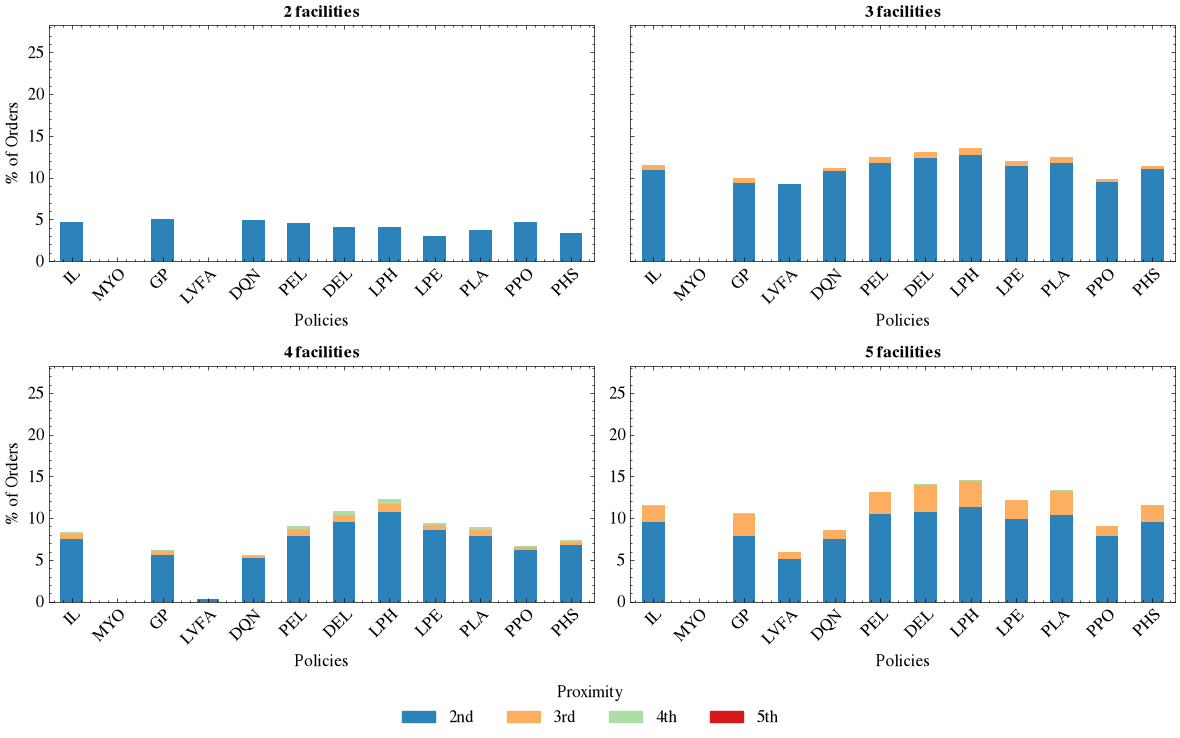

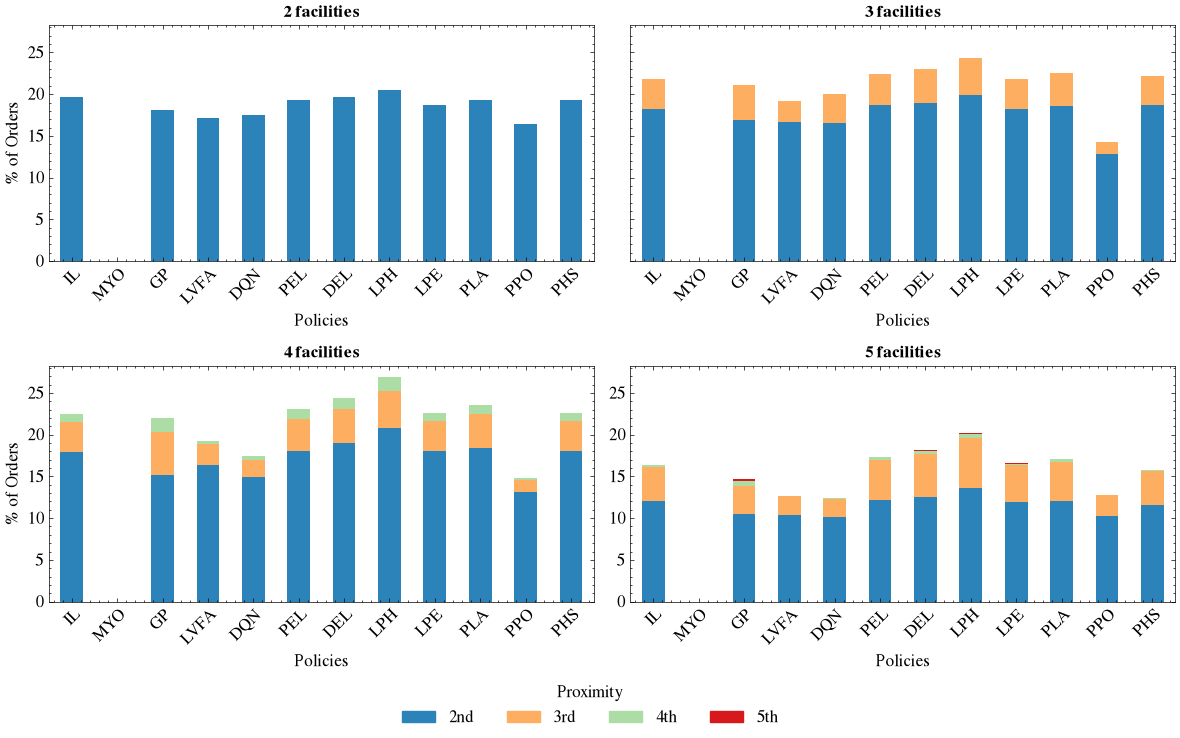

In [9]:
def _ordinal(n):
    n = int(n)
    if 10 <= n % 100 <= 20:
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suffix}"

def build_non_closest_df(df_cfg, num_warehouses, policy_order_with_phs):
    rows = []

    for policy in policy_order_with_phs:
        policy_rows = df_cfg[df_cfg["policy"] == policy]
        if policy_rows.empty:
            continue

        # Pool every matching row's ranks together (e.g. one row per num_customers
        # when df_cfg spans multiple order counts), rather than only reading the
        # first row, so the resulting percentages reflect all pooled orders.
        flat_ranks = []
        for ranks in policy_rows["all_distance_ranks_single_vector"]:
            if not isinstance(ranks, list):
                continue
            for r in ranks:
                if isinstance(r, list):
                    flat_ranks.extend(r)
                else:
                    flat_ranks.append(int(r))

        total = len(flat_ranks)
        if total == 0:
            continue

        counts = Counter(r for r in flat_ranks if 2 <= int(r) <= num_warehouses)
        for prox_rank, count in counts.items():
            rows.append(
                {
                    "policy": policy,
                    "proximity": _ordinal(prox_rank),
                    "rank_pct": 100 * count / total,
                }
            )

    return pd.DataFrame(rows)

policy_order = ["imitation_learning", "myopic", "genetic_programming", "linear_value_function_approximation", "deep_q_networks", "point_estimate_lookahead", "distributional_estimate_lookahead", "linear_programming_heuristic", "linear_programming_exact", "parameterized_lookahead_approximation", "proximal_policy_optimization", "perfect_hindsight"]
labels_dict = {'myopic': 'MYO', 'imitation_learning': 'IL', 'genetic_programming': 'GP', 'point_estimate_lookahead': 'PEL', 'distributional_estimate_lookahead': 'DEL', 'linear_value_function_approximation': 'LVFA', 'deep_q_networks': 'DQN', 'linear_programming_heuristic': 'LPH', 'linear_programming_exact': 'LPE', 'parameterized_lookahead_approximation': 'PLA', 'perfect_hindsight': 'PHS', 'proximal_policy_optimization': 'PPO'}


x_labels_with_phs = [labels_dict.get(p, p) for p in policy_order]
x_pos_with_phs = list(range(len(policy_order)))

# Fixed proximity-rank category order and one color per category, shared across every
# subplot/figure below. pivot_table only creates a column for a rank that actually
# occurs in that subplot's data, so without a fixed order+color mapping, the same
# tab10 color would land on a different proximity rank in different subplots, and a
# legend built from a single subplot's handles could silently drop categories that
# only show up elsewhere.
proximity_categories = [_ordinal(r) for r in range(2, max(num_warehouses_options) + 1)]
category_colors = dict(zip(proximity_categories, get_colors(len(proximity_categories))))

# Pass 1: build every (capacity_distribution, num_warehouses) pivot up front, pooling
# every num_customers instance together, reindexed to the fixed category set, and
# track the tallest stacked bar seen - so every subplot in both figures below can
# share one y-axis limit.
pivots = {}
global_ymax = 0
for capacity_distribution in capacity_distribution_options:
    for num_warehouses in num_warehouses_options:
        df_cfg = results[
            (results["num_warehouses"] == num_warehouses)
            & (results["capacity_distribution"] == capacity_distribution)
        ]
        df_plot = build_non_closest_df(df_cfg, num_warehouses, policy_order)
        if df_plot.empty:
            continue

        pivot = (
            df_plot.pivot_table(
                index="policy",
                columns="proximity",
                values="rank_pct",
                aggfunc="sum",
                fill_value=0,
            )
            .reindex(index=policy_order, columns=proximity_categories)
            .fillna(0)
        )
        pivots[(capacity_distribution, num_warehouses)] = pivot
        global_ymax = max(global_ymax, pivot.sum(axis=1).max())

global_ymax *= 1.05  # small headroom so the tallest bar isn't flush with the frame

# Pass 2: plot - one figure per capacity distribution (2 total), each a 2x2 grid over
# num_warehouses_options ([2, 3, 4, 5] per the paper), pooling every num_customers
# instance together into each subplot; every subplot shares the y-limit and the
# proximity-rank -> color mapping computed above.
for capacity_distribution in capacity_distribution_options:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, num_warehouses in zip(axes, num_warehouses_options):
        pivot = pivots.get((capacity_distribution, num_warehouses))
        if pivot is None:
            ax.set_axis_off()
            continue

        pivot.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            legend=False,
            color=[category_colors[c] for c in pivot.columns],
        )

        ax.set_title(f"{num_warehouses} facilities", fontsize=TITLE_FONT_SIZE)
        ax.title.set_fontweight("bold")
        ax.set_xlabel("Policies", fontsize=FONT_SIZE_LABEL)
        ax.set_ylabel("% of Orders", fontsize=FONT_SIZE_LABEL)
        ax.set_xticklabels(x_labels_with_phs, rotation=45, ha="right", rotation_mode="anchor", fontsize=FONT_SIZE_TICK)
        ax.tick_params(axis="y", labelsize=FONT_SIZE_TICK, labelleft=True)
        ax.set_ylim(0, global_ymax)

    # turn off any axes left over when fewer than 4 num_warehouses configs are loaded
    for ax in axes[len(num_warehouses_options):]:
        ax.set_axis_off()

    handles = [mpatches.Patch(color=category_colors[cat], label=cat) for cat in proximity_categories]
    fig.legend(handles=handles, title="Proximity", loc="lower center", bbox_to_anchor=(0.5, +0.01), ncol=len(proximity_categories), fontsize=FONT_SIZE_LEGEND, title_fontsize=FONT_SIZE_LEGEND_TITLE)
    #fig.suptitle(f"{capacity_distribution} capacity (all order counts pooled)")
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.savefig(f'results/plots/proximity_rank_plots/proximity_rank_distribution_{capacity_distribution}.pdf', bbox_inches='tight', dpi=600)
    #plt.show()

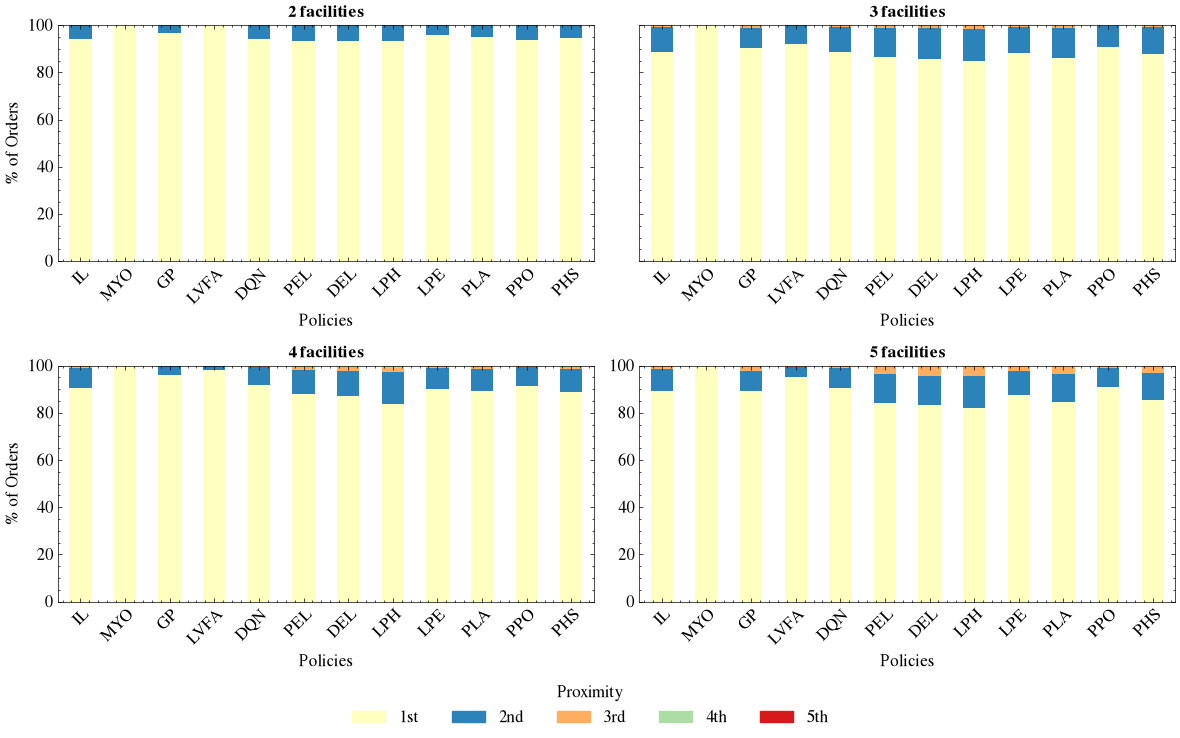

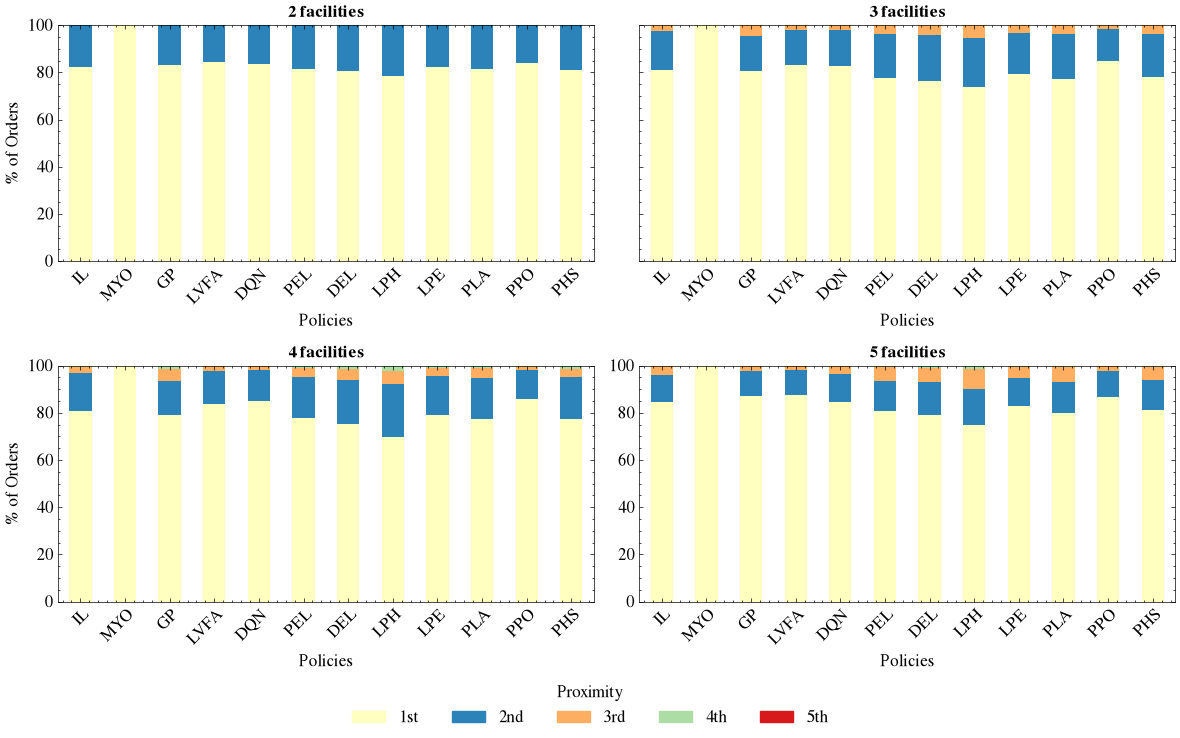

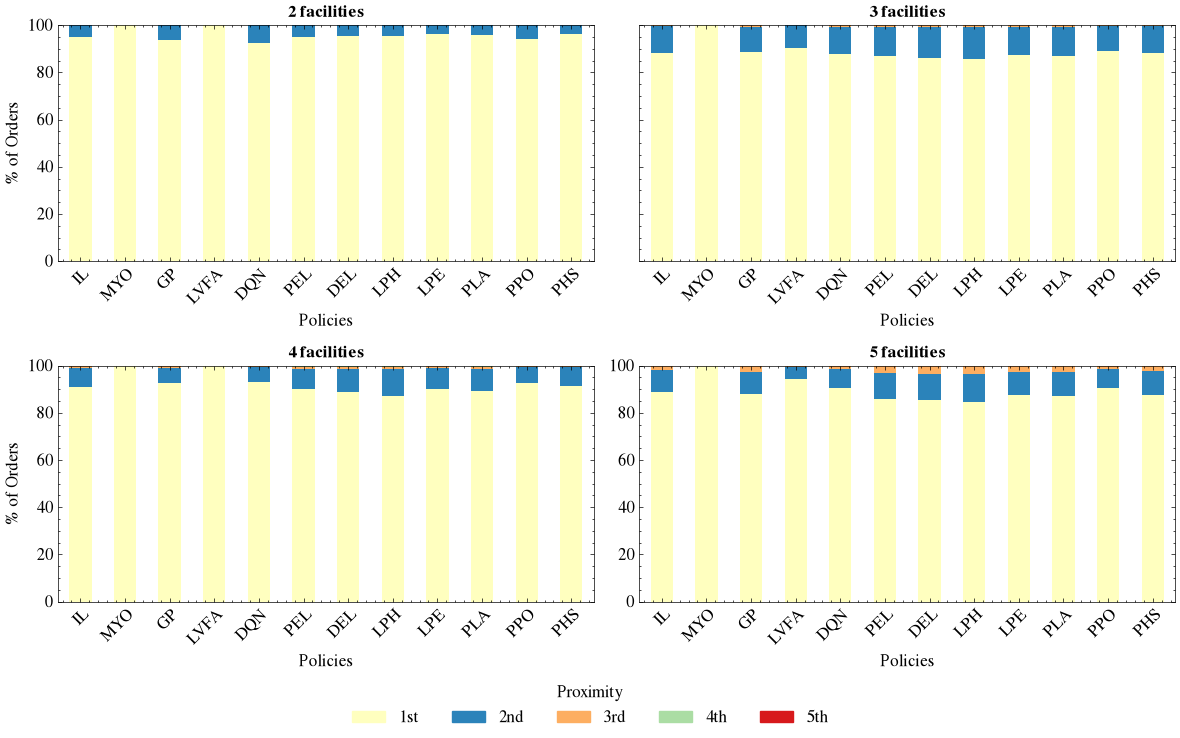

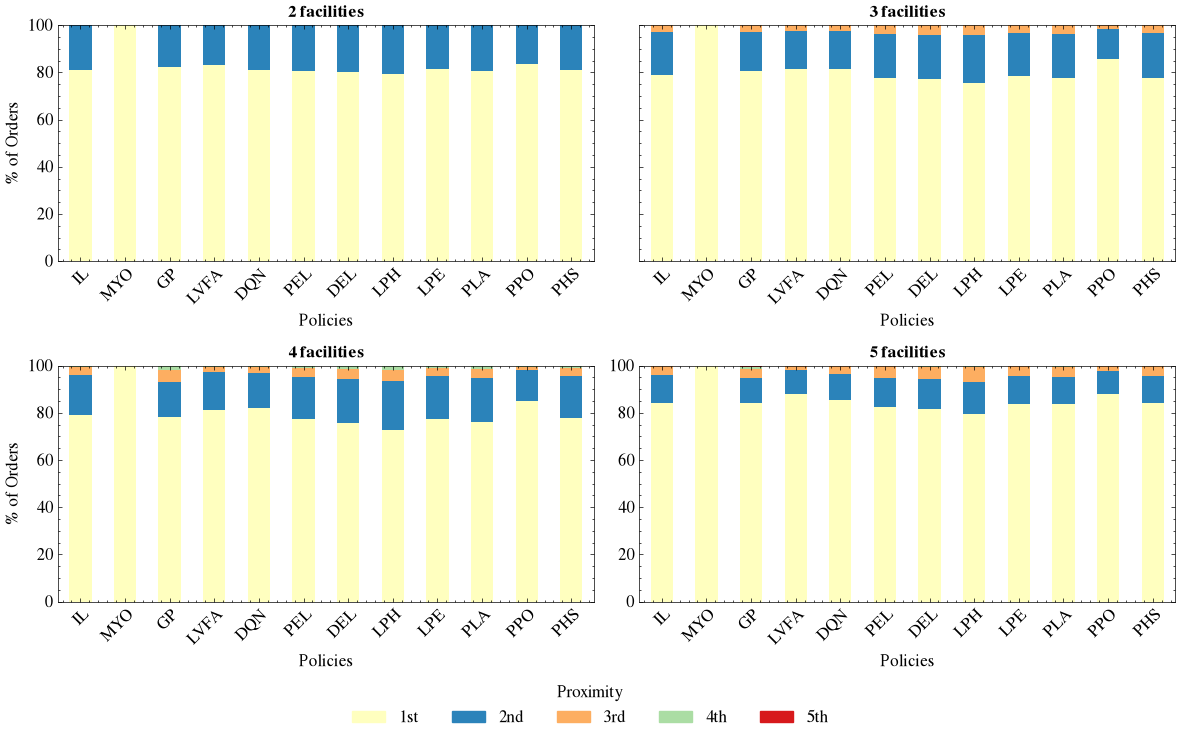

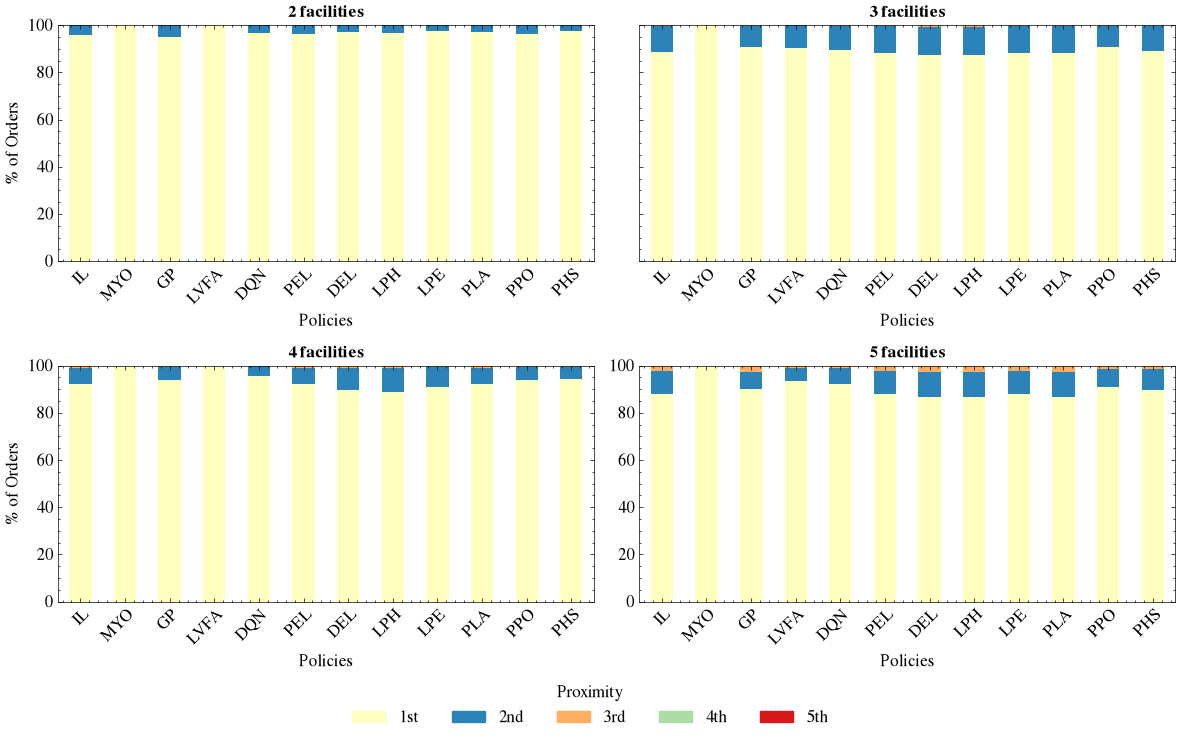

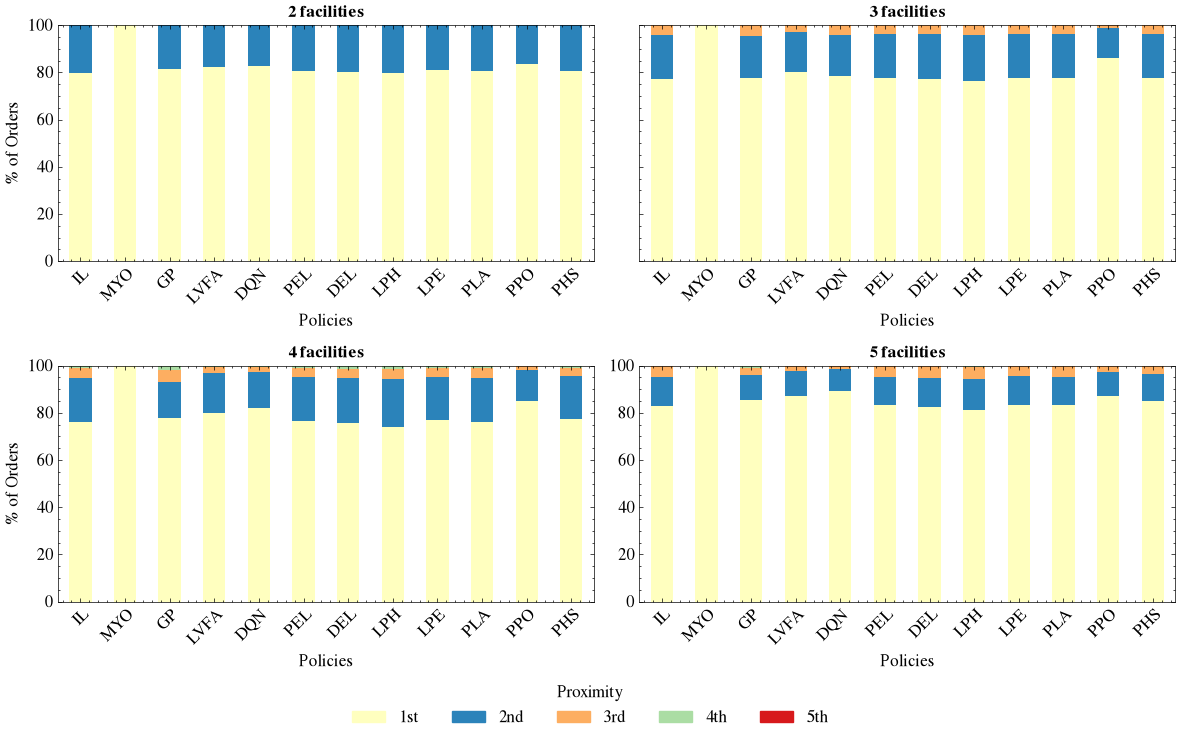

In [10]:
# Same structure as the cell above, but showing the *full* proximity-rank distribution
# (including rank 1 = closest facility) instead of only what wasn't the closest - every
# bar therefore stacks to (approximately) 100%.
def build_full_proximity_df(df_cfg, num_warehouses, policy_order_with_phs):
    rows = []

    for policy in policy_order_with_phs:
        row = df_cfg[df_cfg["policy"] == policy]
        if row.empty:
            continue

        ranks = row.iloc[0]["all_distance_ranks_single_vector"]
        if not isinstance(ranks, list):
            continue

        flat_ranks = []
        for r in ranks:
            if isinstance(r, list):
                flat_ranks.extend(r)
            else:
                flat_ranks.append(int(r))

        total = len(flat_ranks)
        if total == 0:
            continue

        counts = Counter(r for r in flat_ranks if 1 <= int(r) <= num_warehouses)
        for prox_rank, count in counts.items():
            rows.append(
                {
                    "policy": policy,
                    "proximity": _ordinal(prox_rank),
                    "rank_pct": 100 * count / total,
                }
            )

    return pd.DataFrame(rows)

# Fixed category order (starts at 1st, unlike proximity_categories above) and colors -
# reuses category_colors' mapping for 2nd/3rd/... so a given rank keeps the same color
# as the chart above, plus one more color for 1st.
proximity_categories_full = [_ordinal(r) for r in range(1, max(num_warehouses_options) + 1)]
category_colors_full = {"1st": get_colors(len(proximity_categories) + 1)[-1], **category_colors}

pivots_full = {}
for num_customers in num_customers_options:
    for capacity_distribution in capacity_distribution_options:
        for num_warehouses in num_warehouses_options:
            df_cfg = results[
                (results["num_customers"] == num_customers)
                & (results["num_warehouses"] == num_warehouses)
                & (results["capacity_distribution"] == capacity_distribution)
            ]
            df_plot = build_full_proximity_df(df_cfg, num_warehouses, policy_order)
            if df_plot.empty:
                continue

            pivot = (
                df_plot.pivot_table(
                    index="policy",
                    columns="proximity",
                    values="rank_pct",
                    aggfunc="sum",
                    fill_value=0,
                )
                .reindex(index=policy_order, columns=proximity_categories_full)
                .fillna(0)
            )
            pivots_full[(num_customers, capacity_distribution, num_warehouses)] = pivot

# Every bar covers the full 1..num_warehouses distribution, so it always stacks to
# (approximately) 100% - one shared y-limit, no pre-pass needed to find it.
for num_customers in num_customers_options:
    for capacity_distribution in capacity_distribution_options:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
        axes = np.atleast_1d(axes).flatten()

        for ax, num_warehouses in zip(axes, num_warehouses_options):
            pivot = pivots_full.get((num_customers, capacity_distribution, num_warehouses))
            if pivot is None:
                ax.set_axis_off()
                continue

            pivot.plot(
                kind="bar",
                stacked=True,
                ax=ax,
                legend=False,
                color=[category_colors_full[c] for c in pivot.columns],
            )

            ax.set_title(f"{num_warehouses} facilities", fontsize=TITLE_FONT_SIZE)
            ax.title.set_fontweight("bold")
            ax.set_xlabel("Policies", fontsize=FONT_SIZE_LABEL)
            ax.set_ylabel("% of Orders", fontsize=FONT_SIZE_LABEL)
            ax.set_xticklabels(x_labels_with_phs, rotation=45, ha="right", rotation_mode="anchor", fontsize=FONT_SIZE_TICK)
            ax.tick_params(axis="y", labelsize=FONT_SIZE_TICK, labelleft=True)
            ax.set_ylim(0, 100)

        for ax in axes[len(num_warehouses_options):]:
            ax.set_axis_off()

        handles = [mpatches.Patch(color=category_colors_full[cat], label=cat) for cat in proximity_categories_full]
        fig.legend(handles=handles, title="Proximity", loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=len(proximity_categories_full), fontsize=FONT_SIZE_LEGEND, title_fontsize=FONT_SIZE_LEGEND_TITLE)
        #fig.suptitle(f"{num_customers} orders | {capacity_distribution} capacity")
        plt.tight_layout(rect=[0, 0.08, 1, 0.95])
        plt.savefig(f'results/plots/proximity_rank_plots/proximity_rank_distribution_full_{num_customers}_{capacity_distribution}.pdf', bbox_inches='tight', dpi=600)
        #plt.show()

Set parameter Username
Set parameter LicenseID to value 2776932
Academic license - for non-commercial use only - expires 2027-02-09
Saved to results/plots/specific_instance_analysis/cumulative_reward_instance10001_w5_c100_uneven.pdf


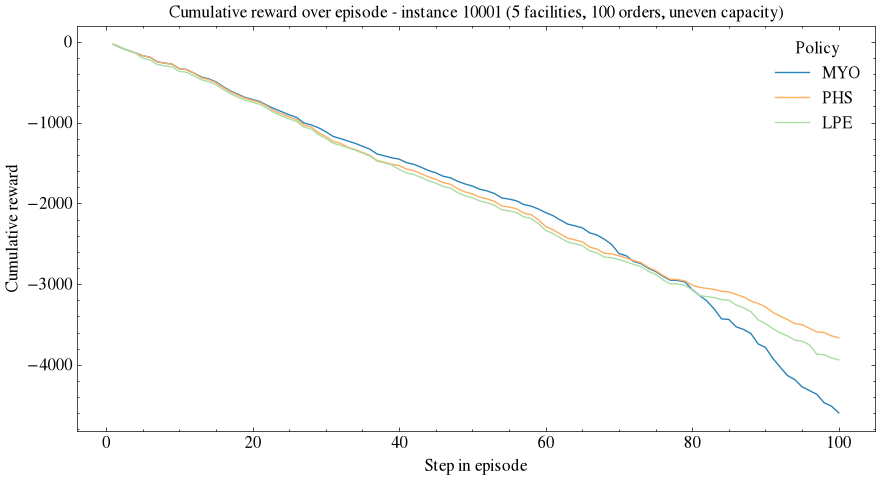

In [8]:
from env import InventoryEnv
from miscelaneous import read_instance
from policies.myopic_policy import MyopicPolicy
from policies.perfect_hindsight_policy import PerfectHindsightPolicy
from policies.linear_programming_exact import LinearProgrammingExactPolicy
from policies.exact_value_function_policy import ExactValueFunctionPolicy
#from policies.genetic_programming_policy import GeneticProgrammingPolicy

INSTANCE_NUM = 10001
INSTANCE_FILE = f"instances/instances_test/instances_seed_{INSTANCE_NUM}.json"
NUM_WAREHOUSES = 5
NUM_CUSTOMERS = 100
CAPACITY_DISTRIBUTION = "uneven"

# name -> factory building that policy given a fresh env (each policy below gets its
# own env instance, since env.warehouses_capacity etc. are stateful) - add/remove
# entries here to change which lines show up on the graph.
SELECTED_POLICIES = {
    "myopic": lambda env: MyopicPolicy(env),
    "perfect_hindsight": lambda env: PerfectHindsightPolicy(env),
    #"genetic_programming": lambda env: GeneticProgrammingPolicy(env, NUM_WAREHOUSES, NUM_CUSTOMERS, CAPACITY_DISTRIBUTION),
    "linear_programming_exact": lambda env: LinearProgrammingExactPolicy(env, NUM_WAREHOUSES),
}

POLICY_LABELS = {
    "myopic": "MYO",
    "perfect_hindsight": "PHS",
    "point_estimate_lookahead": "PEL",
    "distributional_estimate_lookahead": "DEL",
    "genetic_programming": "GP",
    "least_squares_policy_iteration": "LSPI",
    "linear_programming_heuristic": "LPH",
    "linear_programming_exact": "LPE",
    "parameterized_lookahead_approximation": "PLA",
    "imitation_learning": "IL",
    "deep_q_networks": "DQN",
    "proximal_policy_optimization": "PPO",
}

instance = read_instance(INSTANCE_FILE)
policy_colors = dict(zip(SELECTED_POLICIES, get_colors(len(SELECTED_POLICIES))))

fig, ax = plt.subplots(figsize=(9, 5))

for name, make_policy in SELECTED_POLICIES.items():
    env = InventoryEnv(NUM_WAREHOUSES, NUM_CUSTOMERS, CAPACITY_DISTRIBUTION, grid_size=200)
    env.set_instance(instance)
    policy = make_policy(env)
    policy.reset(instance)
    state, info = env.reset()

    steps = []
    cumulative_rewards = []
    cumulative_reward = 0
    step = 0
    done = False
    while not done:
        action = policy.act(state)
        state, reward, done, truncated, _ = env.step(action)
        cumulative_reward += reward
        step += 1
        steps.append(step)
        cumulative_rewards.append(cumulative_reward)

    ax.plot(steps, cumulative_rewards, label=POLICY_LABELS.get(name, name), color=policy_colors[name])

ax.set_xlabel("Step in episode", fontsize=FONT_SIZE_LABEL)
ax.set_ylabel("Cumulative reward", fontsize=FONT_SIZE_LABEL)
ax.tick_params(axis="both", labelsize=FONT_SIZE_TICK)
ax.set_title(f"Cumulative reward over episode - instance {INSTANCE_NUM} ({NUM_WAREHOUSES} facilities, {NUM_CUSTOMERS} orders, {CAPACITY_DISTRIBUTION} capacity)")
ax.legend(title="Policy", fontsize=FONT_SIZE_LEGEND, title_fontsize=FONT_SIZE_LEGEND_TITLE)
plt.tight_layout()

output_dir = "results/plots/specific_instance_analysis"
os.makedirs(output_dir, exist_ok=True)
output_path = f"{output_dir}/cumulative_reward_instance{INSTANCE_NUM}_w{NUM_WAREHOUSES}_c{NUM_CUSTOMERS}_{CAPACITY_DISTRIBUTION}.pdf"
fig.savefig(output_path, dpi=600, bbox_inches="tight")
print(f"Saved to {output_path}")

#plt.show()

In [ ]:
INSTANCE_NUM = 10001
INSTANCE_FILE = f"instances/instances_test/instances_seed_{INSTANCE_NUM}.json"
NUM_WAREHOUSES = 5
NUM_CUSTOMERS = 50
CAPACITY_DISTRIBUTION = "uneven"
REFERENCE_POLICY = "myopic"

# name -> factory building that policy given a fresh env (each policy below gets its
# own env instance, since env.warehouses_capacity etc. are stateful) - add/remove
# entries here to change which lines show up on the graph.
SELECTED_POLICIES = {
    "myopic": lambda env: MyopicPolicy(env),
    "exact_value_function": lambda env: ExactValueFunctionPolicy(env, NUM_WAREHOUSES, NUM_CUSTOMERS, CAPACITY_DISTRIBUTION),
}

SELECTED_POLICIES_WITHOUT_BASELINE = {k: v for k, v in SELECTED_POLICIES.items() if k != REFERENCE_POLICY}

POLICY_LABELS = {
    "myopic": "MYO",
    "perfect_hindsight": "PHS",
    "point_estimate_lookahead": "PEL",
    "distributional_estimate_lookahead": "DEL",
    "genetic_programming": "GP",
    "least_squares_policy_iteration": "LSPI",
    "linear_programming_heuristic": "LPH",
    "linear_programming_exact": "LPE",
    "parameterized_lookahead_approximation": "PLA",
    "imitation_learning": "IL",
    "deep_q_networks": "DQN",
    "proximal_policy_optimization": "PPO",
    "exact_value_function": "OPT"
}

assert REFERENCE_POLICY in SELECTED_POLICIES, "REFERENCE_POLICY must be one of SELECTED_POLICIES"

from miscelaneous import read_instance
from env import InventoryEnv
from policies.myopic_policy import MyopicPolicy
from policies.exact_value_function_policy import ExactValueFunctionPolicy

instance = read_instance(INSTANCE_FILE)
policy_colors = dict(zip(SELECTED_POLICIES_WITHOUT_BASELINE.keys(), get_colors(len(SELECTED_POLICIES_WITHOUT_BASELINE))))

cumulative_by_policy = {}

for name, make_policy in SELECTED_POLICIES.items():
    env = InventoryEnv(NUM_WAREHOUSES, NUM_CUSTOMERS, CAPACITY_DISTRIBUTION, grid_size=200)
    env.set_instance(instance)
    policy = make_policy(env)
    policy.reset(instance)
    state, info = env.reset()

    cumulative_rewards = []
    cumulative_reward = 0
    done = False
    while not done:
        action = policy.act(state)
        state, reward, done, truncated, _ = env.step(action)
        cumulative_reward += reward
        cumulative_rewards.append(cumulative_reward)

    cumulative_by_policy[name] = cumulative_rewards

reference_curve = cumulative_by_policy[REFERENCE_POLICY]

fig, ax = plt.subplots(figsize=(9, 5))

for name, cumulative_rewards in cumulative_by_policy.items():
    if name == REFERENCE_POLICY:
        continue
    steps = range(1, len(cumulative_rewards) + 1)
    advantage = [c - r for c, r in zip(cumulative_rewards, reference_curve)]
    ax.plot(steps, advantage, label=POLICY_LABELS.get(name, name), color=policy_colors[name])

ax.axhline(0, color="black", linewidth=1, linestyle="--", label=POLICY_LABELS.get(REFERENCE_POLICY, REFERENCE_POLICY))
ax.set_xlabel("Assigned orders", fontsize=FONT_SIZE_LABEL)
ax.set_ylabel(f"Cumulative reward advantage over {POLICY_LABELS.get(REFERENCE_POLICY, REFERENCE_POLICY)}", fontsize=FONT_SIZE_LABEL)
ax.tick_params(axis="both", labelsize=FONT_SIZE_TICK)
#ax.set_title(f"Cumulative reward relative to {POLICY_LABELS.get(REFERENCE_POLICY, REFERENCE_POLICY)} - instance {INSTANCE_NUM} ({NUM_WAREHOUSES} facilities, {NUM_CUSTOMERS} orders, {CAPACITY_DISTRIBUTION} capacity)")
ax.legend(title="Policy", loc="lower center", bbox_to_anchor=(0.5, -0.30), ncol=3, fontsize=FONT_SIZE_LEGEND, title_fontsize=FONT_SIZE_LEGEND_TITLE)
plt.tight_layout()

output_dir = "results/plots/specific_instance_analysis"
os.makedirs(output_dir, exist_ok=True)
output_path = f"{output_dir}/cumulative_reward_vs_myo_instance{INSTANCE_NUM}_w{NUM_WAREHOUSES}_c{NUM_CUSTOMERS}_{CAPACITY_DISTRIBUTION}.pdf"
fig.savefig(output_path, dpi=600, bbox_inches="tight")
print(f"Saved to {output_path}")

#plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/miguellunet/Documents/Current projects/Tutorial - SDM in Online Facility Assignment/InventoryRouting/training/exact_value_function_training/values_w_5_c_50_d_uneven_gamma_1_squares_10000_agg_1.csv'

Saved to results/plots/specific_instance_analysis/reward_rate_instance30_w5_c100_uneven.pdf


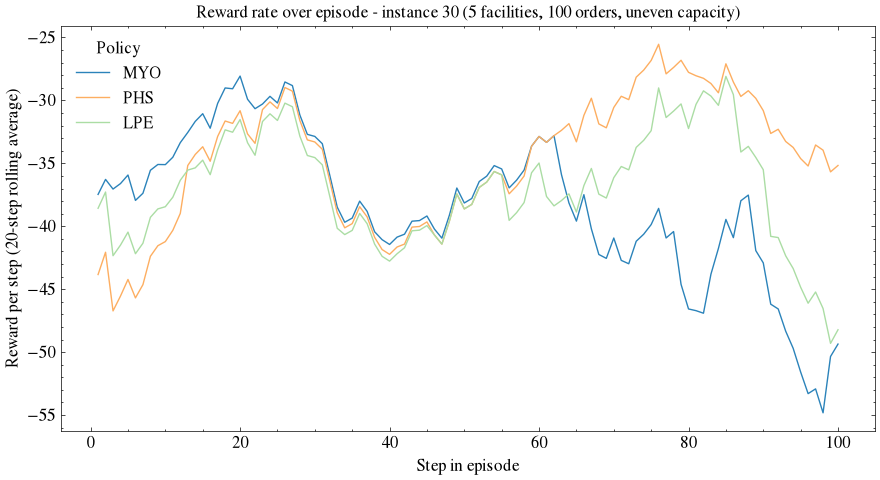

In [ ]:
INSTANCE_NUM = 30
INSTANCE_FILE = f"instances/instances_extra/instances_seed_{INSTANCE_NUM}.json"
NUM_WAREHOUSES = 5
NUM_CUSTOMERS = 100
CAPACITY_DISTRIBUTION = "uneven"
ROLLING_WINDOW = 20  # steps averaged into each point of the reward-rate curve

# name -> factory building that policy given a fresh env (each policy below gets its
# own env instance, since env.warehouses_capacity etc. are stateful) - add/remove
# entries here to change which lines show up on the graph.
SELECTED_POLICIES = {
    "myopic": lambda env: MyopicPolicy(env),
    "exact_value_function": lambda env: ExactValueFunctionPolicy(env, NUM_WAREHOUSES, NUM_CUSTOMERS, CAPACITY_DISTRIBUTION),
}

POLICY_LABELS = {
    "myopic": "MYO",
    "perfect_hindsight": "PHS",
    "point_estimate_lookahead": "PEL",
    "distributional_estimate_lookahead": "DEL",
    "genetic_programming": "GP",
    "least_squares_policy_iteration": "LSPI",
    "linear_programming_heuristic": "LPH",
    "linear_programming_exact": "LPE",
    "parameterized_lookahead_approximation": "PLA",
    "imitation_learning": "IL",
    "deep_q_networks": "DQN",
    "proximal_policy_optimization": "PPO",
}

instance = read_instance(INSTANCE_FILE)
policy_colors = dict(zip(SELECTED_POLICIES, get_colors(len(SELECTED_POLICIES))))

fig, ax = plt.subplots(figsize=(9, 5))

for name, make_policy in SELECTED_POLICIES.items():
    env = InventoryEnv(NUM_WAREHOUSES, NUM_CUSTOMERS, CAPACITY_DISTRIBUTION, grid_size=200)
    env.set_instance(instance)
    policy = make_policy(env)
    policy.reset(instance)
    state, info = env.reset()

    step_rewards = []
    done = False
    while not done:
        action = policy.act(state)
        state, reward, done, truncated, _ = env.step(action)
        step_rewards.append(reward)

    reward_rate = pd.Series(step_rewards).rolling(ROLLING_WINDOW, min_periods=1, center=True).mean()
    steps = range(1, len(reward_rate) + 1)

    ax.plot(steps, reward_rate, label=POLICY_LABELS.get(name, name), color=policy_colors[name])

ax.set_xlabel("Step in episode", fontsize=FONT_SIZE_LABEL)
ax.set_ylabel(f"Reward per step ({ROLLING_WINDOW}-step rolling average)", fontsize=FONT_SIZE_LABEL)
ax.tick_params(axis="both", labelsize=FONT_SIZE_TICK)
ax.set_title(f"Reward rate over episode - instance {INSTANCE_NUM} ({NUM_WAREHOUSES} facilities, {NUM_CUSTOMERS} orders, {CAPACITY_DISTRIBUTION} capacity)")
ax.legend(title="Policy", fontsize=FONT_SIZE_LEGEND, title_fontsize=FONT_SIZE_LEGEND_TITLE)
plt.tight_layout()

output_dir = "results/plots/specific_instance_analysis"
os.makedirs(output_dir, exist_ok=True)
output_path = f"{output_dir}/reward_rate_instance{INSTANCE_NUM}_w{NUM_WAREHOUSES}_c{NUM_CUSTOMERS}_{CAPACITY_DISTRIBUTION}.pdf"
fig.savefig(output_path, dpi=600,bbox_inches="tight")
print(f"Saved to {output_path}")

#plt.show()


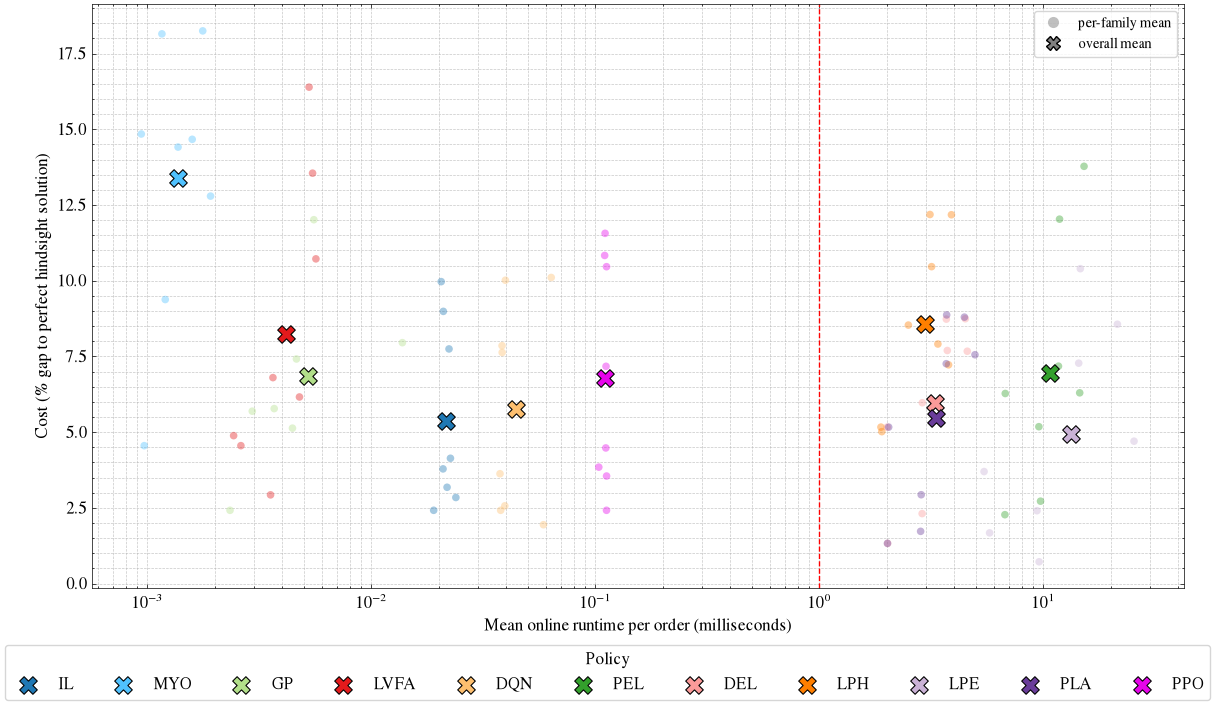

In [4]:
# =====================================================================================
# Figure 8b (runtime vs. performance) - faint per-family scatter, reading `results`
# -------------------------------------------------------------------------------------
# Same axes as the scatter above, but instead of an error bar this shows the actual
# spread across the instance families: one faint, softened-color dot per policy per
# family (that family's own mean_time / avg_gap_phs, read straight off `results` - one
# row per (policy, family), built by the consolidation cell above), plus one vivid
# cross per policy at its overall mean (equal weight per family). The vivid cross sits
# at exactly the same (x, y) as the error-bar point plotted in the cell above.
# =====================================================================================
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

policies = ["imitation_learning",
            "myopic", "genetic_programming",
            "linear_value_function_approximation","deep_q_networks",
            "point_estimate_lookahead","distributional_estimate_lookahead",
            "linear_programming_heuristic", "linear_programming_exact","parameterized_lookahead_approximation", "proximal_policy_optimization"]
labels_dict = {'myopic': 'MYO', 'imitation_learning': 'IL', 'genetic_programming': 'GP',
               'point_estimate_lookahead': 'PEL', 'distributional_estimate_lookahead': 'DEL',
               'linear_value_function_approximation': 'LVFA', 'deep_q_networks': 'DQN',
               'linear_programming_heuristic': 'LPH', 'linear_programming_exact': 'LPE',
               'parameterized_lookahead_approximation': 'PLA', 'proximal_policy_optimization': 'PPO'}
all_policy_colors = [
    '#1f78b4', "#50c2ff", '#b2df8a', '#e31a1c', '#fdbf6f',
   '#33a02c', '#fb9a99', '#ff7f00', '#cab2d6', '#6a3d9a',
    "#e704eb", "#000000"
]

fig, ax = plt.subplots(figsize=(12, 8))
for p in policies:
    sub = results[results['policy'] == p]
    if sub.empty:
        continue
    color = all_policy_colors[policies.index(p)]

    # faint per-family dots (one per instance family) - softened via low alpha, no edge
    ax.scatter(
        sub['mean_time'] / 1_000_000,          # ns -> ms, same conversion as Figure 8
        sub['avg_gap_phs'],
        color=color,
        alpha=0.40,
        s=30,
        edgecolors='none',
        zorder=2,
    )

    # vivid marker at the policy's overall mean - identical (x, y) to the error-bar
    # point plotted for this same policy in the cell above
    ax.scatter(
        sub['mean_time'].mean() / 1_000_000,
        sub['avg_gap_phs'].mean(),
        color=color,
        marker='X',
        s=160,
        edgecolors='black',
        linewidths=0.8,
        label=labels_dict[p],
        zorder=3,
    )

ax.set_xscale('log')
ax.axvline(1, color='red', linestyle='--')
ax.set_xlabel('Mean online runtime per order (milliseconds)', fontsize=FONT_SIZE_LABEL)
ax.set_ylabel('Cost (% gap to perfect hindsight solution)', fontsize=FONT_SIZE_LABEL)
ax.tick_params(labelsize=FONT_SIZE_TICK)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

fig.subplots_adjust(left=0.07, right=0.98, top=0.95, bottom=0.22)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Policy', title_fontsize=FONT_SIZE_LEGEND_TITLE,
           loc='lower center', fontsize=FONT_SIZE_LEGEND,
           bbox_to_anchor=(0.5, 0.07), ncol=11, frameon=True)

marker_legend = [
    Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='gray', markeredgecolor='none',
           alpha=0.5, markersize=8, label='per-family mean'),
    Line2D([0], [0], marker='X', linestyle='none', markerfacecolor='gray', markeredgecolor='black',
           markersize=10, label='overall mean'),
]
ax.legend(handles=marker_legend, loc='upper right', fontsize=FONT_SIZE_LEGEND - 2, frameon=True)

fig.savefig('results/plots/scatter_time_performance_family_dots.pdf', bbox_inches='tight', dpi=600)
# plt.show()